## Section 1: Import Libraries and Configuration

Import all necessary libraries and set up basic configuration parameters.

In [4]:
import os
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Filepaths
DATA_PATH = 'synthetic_bus_data.csv'
MODEL_PATH = 'xgb_bus_model.joblib'

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Section 2: Load or Generate Data

Load the existing CSV data generated by `datasetGen.py`. If it doesn't exist, we can generate it here too.

In [5]:
# Load the data from CSV
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f'✓ Loaded data from {DATA_PATH}')
    print(f'  Total records: {len(df):,}')
    print(f'\nFirst few rows:')
    print(df.head())
    print(f'\nDataset info:')
    print(df.info())
else:
    print(f'❌ File {DATA_PATH} not found!')
    print('Run datasetGen.py first to generate the dataset.')

✓ Loaded data from synthetic_bus_data.csv
  Total records: 78,948

First few rows:
  route_id  stop_id day_of_week time_of_day   weather  passenger_count
0        A        1      Sunday        8-10  not_rain                8
1        A        2      Sunday       18-20  not_rain               13
2        A        3      Sunday       20-22  not_rain               15
3        A        4      Sunday       12-14  not_rain               24
4        A        5      Sunday       18-20  not_rain               27

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78948 entries, 0 to 78947
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   route_id         78948 non-null  object
 1   stop_id          78948 non-null  int64 
 2   day_of_week      78948 non-null  object
 3   time_of_day      78948 non-null  object
 4   weather          78948 non-null  object
 5   passenger_count  78948 non-null  int64 
dtypes: 

## Section 3: Explore the Data

Let's understand what our dataset contains and check basic statistics.

In [6]:
# Check data statistics
print("Dataset Statistics:")
print(df.describe())

print("\n" + "="*50)
print("Unique values in each column:")
print("="*50)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\n" + "="*50)
print("Sample of categorical values:")
print("="*50)
print(f"Routes: {df['route_id'].unique()}")
print(f"Days of week: {df['day_of_week'].unique()}")
print(f"Time bins: {df['time_of_day'].unique()}")
print(f"Weather conditions: {df['weather'].unique()}")

Dataset Statistics:
            stop_id  passenger_count
count  78948.000000     78948.000000
mean       5.055556        38.642157
std        2.676504        22.992056
min        1.000000         0.000000
25%        3.000000        18.000000
50%        5.000000        38.000000
75%        7.000000        58.000000
max       10.000000        75.000000

Unique values in each column:
route_id: 2 unique values
stop_id: 10 unique values
day_of_week: 7 unique values
time_of_day: 8 unique values
weather: 2 unique values
passenger_count: 76 unique values

Sample of categorical values:
Routes: ['A' 'B']
Days of week: ['Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday']
Time bins: ['8-10' '18-20' '20-22' '12-14' '10-12' '14-16' '16-18' '6-8']
Weather conditions: ['not_rain' 'rain']


## Section 4: Feature Engineering

Convert categorical features into numerical format using one-hot encoding so the machine learning model can understand them.

In [7]:
TARGET = 'passenger_count'

# Define feature types
categorical_features = ['route_id', 'day_of_week', 'time_of_day', 'weather']
numerical_features = ['stop_id']

# Separate features (X) and target (y)
X = df[categorical_features + numerical_features]
y = df[TARGET]

# One-hot encode categorical features
# drop_first=True removes one category to avoid multicollinearity
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print('✓ Feature engineering complete!')
print(f'Original features: {len(categorical_features + numerical_features)}')
print(f'Encoded features: {len(X_encoded.columns)}')
print(f'\nEncoded feature names:')
print(X_encoded.columns.tolist())
print(f'\nFirst few rows of encoded features:')
X_encoded.head()

✓ Feature engineering complete!
Original features: 5
Encoded features: 16

Encoded feature names:
['stop_id', 'route_id_B', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'time_of_day_12-14', 'time_of_day_14-16', 'time_of_day_16-18', 'time_of_day_18-20', 'time_of_day_20-22', 'time_of_day_6-8', 'time_of_day_8-10', 'weather_rain']

First few rows of encoded features:


,stop_id,route_id_B,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,time_of_day_12-14,time_of_day_14-16,time_of_day_16-18,time_of_day_18-20,time_of_day_20-22,time_of_day_6-8,time_of_day_8-10,weather_rain
0,1,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
1,2,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
2,3,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
3,4,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False
4,5,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False


## Section 5: Split Data into Training and Testing Sets

Split the data: 80% for training the model, 20% for testing its performance.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE
)

print('✓ Data split complete!')
print(f'Training set size: {len(X_train):,} samples ({len(X_train)/len(X_encoded)*100:.1f}%)')
print(f'Testing set size: {len(X_test):,} samples ({len(X_test)/len(X_encoded)*100:.1f}%)')
print(f'\nTraining features shape: {X_train.shape}')
print(f'Testing features shape: {X_test.shape}')

✓ Data split complete!
Training set size: 63,158 samples (80.0%)
Testing set size: 15,790 samples (20.0%)

Training features shape: (63158, 16)
Testing features shape: (15790, 16)


## Section 6: Train the XGBoost Model

Train an XGBoost regression model to predict passenger counts. The model uses early stopping to prevent overfitting.

In [10]:
print('Training XGBoost model...')
print('This may take a minute or two...\n')

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=50  # Moved here in newer XGBoost versions
)

# Fit model with evaluation set
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=10
)

print('\n✓ Model training complete!')

Training XGBoost model...
This may take a minute or two...

[0]	validation_0-rmse:22.92288
[10]	validation_0-rmse:18.21742
[10]	validation_0-rmse:18.21742
[20]	validation_0-rmse:14.28144
[20]	validation_0-rmse:14.28144
[30]	validation_0-rmse:11.85625
[30]	validation_0-rmse:11.85625
[40]	validation_0-rmse:10.53530
[40]	validation_0-rmse:10.53530
[50]	validation_0-rmse:9.12006
[50]	validation_0-rmse:9.12006
[60]	validation_0-rmse:8.28402
[60]	validation_0-rmse:8.28402
[70]	validation_0-rmse:7.86667
[70]	validation_0-rmse:7.86667
[80]	validation_0-rmse:7.56364
[80]	validation_0-rmse:7.56364
[90]	validation_0-rmse:7.40449
[90]	validation_0-rmse:7.40449
[100]	validation_0-rmse:7.29076
[100]	validation_0-rmse:7.29076
[110]	validation_0-rmse:7.21331
[110]	validation_0-rmse:7.21331
[120]	validation_0-rmse:7.17885
[120]	validation_0-rmse:7.17885
[130]	validation_0-rmse:7.14112
[130]	validation_0-rmse:7.14112
[140]	validation_0-rmse:7.11494
[140]	validation_0-rmse:7.11494
[150]	validation_0-rmse

## Section 7: Evaluate Model Performance

Test the model on unseen data and calculate accuracy metrics.

In [11]:
# Make predictions on test set
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('='*50)
print('MODEL PERFORMANCE METRICS')
print('='*50)
print(f'Mean Absolute Error (MAE): {mae:.2f} passengers')
print(f'  → On average, predictions are off by {mae:.2f} passengers')
print(f'\nR² Score: {r2:.4f}')
print(f'  → Model explains {r2*100:.2f}% of the variance in passenger counts')
print('='*50)

# Show some example predictions
print('\nSample Predictions vs Actual:')
comparison = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted': y_pred[:10].round(1),
    'Difference': (y_test[:10].values - y_pred[:10]).round(1)
})
print(comparison)

MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): 5.43 passengers
  → On average, predictions are off by 5.43 passengers

R² Score: 0.9056
  → Model explains 90.56% of the variance in passenger counts

Sample Predictions vs Actual:
   Actual  Predicted  Difference
0      75  67.000000         8.0
1      12   8.100000         3.9
2      37  45.799999        -8.8
3      49  58.799999        -9.8
4      29  21.000000         8.0
5      24  25.799999        -1.8
6       4   3.900000         0.1
7       7   2.800000         4.2
8      24  31.100000        -7.1
9      66  62.099998         3.9


## Section 8: Visualize Results

Create a scatter plot to visualize how well predictions match actual values.

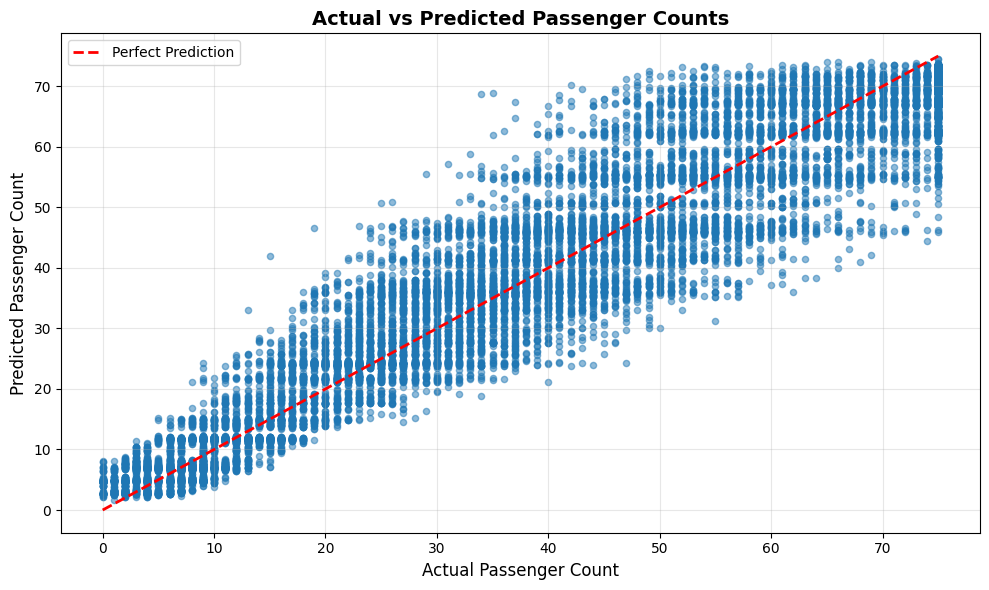

✓ Visualization complete!


In [12]:
# Plot predicted vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Passenger Count', fontsize=12)
plt.ylabel('Predicted Passenger Count', fontsize=12)
plt.title('Actual vs Predicted Passenger Counts', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('✓ Visualization complete!')

## Section 9: Save the Trained Model

Save the model to disk so it can be used later without retraining.

In [13]:
joblib.dump(model, MODEL_PATH)
print(f'✓ Model saved to {MODEL_PATH}')
print(f'  File size: {os.path.getsize(MODEL_PATH) / 1024:.2f} KB')
print('\nYou can now load this model anytime using:')
print(f'  model = joblib.load("{MODEL_PATH}")')

✓ Model saved to xgb_bus_model.joblib
  File size: 862.00 KB

You can now load this model anytime using:
  model = joblib.load("xgb_bus_model.joblib")


## Section 10: Make Predictions on New Data

Test the model with a custom input to predict passenger count for specific scenarios.

In [14]:
def prepare_single_sample(sample_dict, encoder_columns):
    """
    Prepare a single sample for prediction using the same encoding as training data.
    
    Args:
        sample_dict: Dictionary with keys matching original features
        encoder_columns: List of column names from the encoded training data
    
    Returns:
        DataFrame ready for prediction
    """
    sample_df = pd.DataFrame([sample_dict])
    sample_X = pd.get_dummies(sample_df[categorical_features + numerical_features], 
                               columns=categorical_features, drop_first=True)
    # Reindex to match training columns, filling missing cols with 0
    sample_X = sample_X.reindex(columns=encoder_columns, fill_value=0)
    return sample_X

# Store encoder columns from training
encoder_columns = X_encoded.columns.tolist()

# Example 1: Monday morning, Route A, rainy weather
example1 = {
    'route_id': 'A',
    'stop_id': 3,
    'day_of_week': 'Monday',
    'time_of_day': '8-10',
    'weather': 'rain'
}

prepared1 = prepare_single_sample(example1, encoder_columns)
pred1 = model.predict(prepared1)[0]

print('='*60)
print('PREDICTION EXAMPLE 1')
print('='*60)
print(f'Input: {example1}')
print(f'Predicted passenger count: {pred1:.1f} passengers')
print('='*60)

# Example 2: Sunday evening, Route B, no rain
example2 = {
    'route_id': 'B',
    'stop_id': 7,
    'day_of_week': 'Sunday',
    'time_of_day': '18-20',
    'weather': 'not_rain'
}

prepared2 = prepare_single_sample(example2, encoder_columns)
pred2 = model.predict(prepared2)[0]

print('\n' + '='*60)
print('PREDICTION EXAMPLE 2')
print('='*60)
print(f'Input: {example2}')
print(f'Predicted passenger count: {pred2:.1f} passengers')
print('='*60)

PREDICTION EXAMPLE 1
Input: {'route_id': 'A', 'stop_id': 3, 'day_of_week': 'Monday', 'time_of_day': '8-10', 'weather': 'rain'}
Predicted passenger count: 36.1 passengers

PREDICTION EXAMPLE 2
Input: {'route_id': 'B', 'stop_id': 7, 'day_of_week': 'Sunday', 'time_of_day': '18-20', 'weather': 'not_rain'}
Predicted passenger count: 66.8 passengers


## Section 11: Feature Importance

Understand which features are most important for predictions.

Top 10 Most Important Features:
              feature  importance
              stop_id    0.490555
 day_of_week_Saturday    0.189993
   day_of_week_Sunday    0.163641
           route_id_B    0.109719
    time_of_day_16-18    0.009787
     time_of_day_8-10    0.008991
day_of_week_Wednesday    0.006610
   day_of_week_Monday    0.005954
 day_of_week_Thursday    0.005252
  day_of_week_Tuesday    0.004991


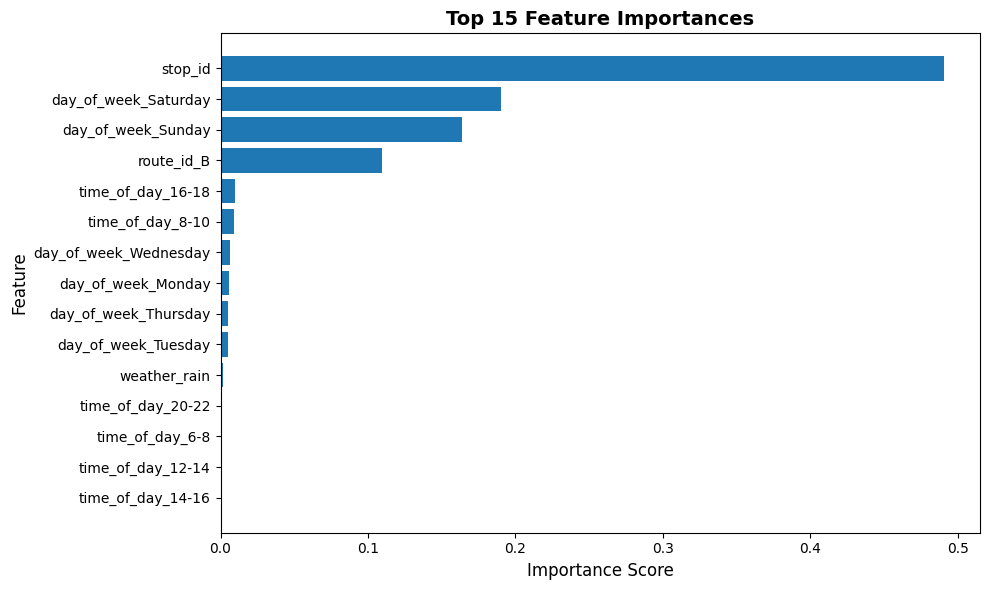


✓ Feature importance analysis complete!


In [15]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Display top 10 features
print('Top 10 Most Important Features:')
print('='*60)
print(feature_importance.head(10).to_string(index=False))
print('='*60)

# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\n✓ Feature importance analysis complete!')

## Summary & Next Steps

**What we accomplished:**
1. ✓ Loaded synthetic bus passenger data
2. ✓ Explored and understood the dataset
3. ✓ Engineered features using one-hot encoding
4. ✓ Split data into training and testing sets
5. ✓ Trained an XGBoost regression model
6. ✓ Evaluated model performance with MAE and R² metrics
7. ✓ Visualized predictions vs actual values
8. ✓ Saved the model for future use
9. ✓ Created a prediction function for new data
10. ✓ Analyzed feature importance

**Next Steps:**
- Fine-tune hyperparameters (learning rate, max depth, etc.)
- Add more features (holidays, special events, temperature)
- Try other algorithms (Random Forest, Neural Networks)
- Deploy the model as a web service (Flask/FastAPI)
- Create a user interface with Streamlit